In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt
import librosa
import pywt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from python_utils.dsp_utils import transform_to_wavelet, reconstruct_from_wavelet
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN
from bss.PredictiveDecorrBSS import PredictiveDecorrBSS

# Generate Sources and Mix Them (10 by 5 case)

In [2]:
seed = 400
np.random.seed(seed)

def load_audio_source(name, duration=5, sr=16000):
    # Load example clips from librosa
    path = librosa.ex(name)
    y, _ = librosa.load(path, duration=duration, sr=sr)
    return y

# Load 3 distinct types of sound
s1 = load_audio_source('fishin') 
s2 = load_audio_source('pistachio')
s3 = load_audio_source('vibeace')  

# Stack into S (n_sources, T)
# Ensure they are all the same length
min_len = min(len(s1), len(s2), len(s3))
S = np.stack([s1[:min_len], s2[:min_len], s3[:min_len]]).astype(np.float64)
print("Length of the sound signals are ", min_len)
# This only required for debugging
wavelet_type = 'db4' # Daubechies 4 is excellent for audio/images
S_wavelet, slices = transform_to_wavelet(S, wavelet=wavelet_type, level=3)

S /= np.max(np.abs(S_wavelet), axis = 1).reshape(-1, 1)
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

NumberofSources = S.shape[0]
NumberofMixtures = 5
# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

# 1. Transform Mixtures to Sparse Domain
wavelet_type = 'db4' # Daubechies 4 is excellent for audio/images
X_wavelet, slices = transform_to_wavelet(X, wavelet=wavelet_type, level=3)

/nfs/ghome/live/bbozkurt/.conda/envs/predictivebss2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Length of the sound signals are  80000
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 30.004388845513226


# Hyperparameters

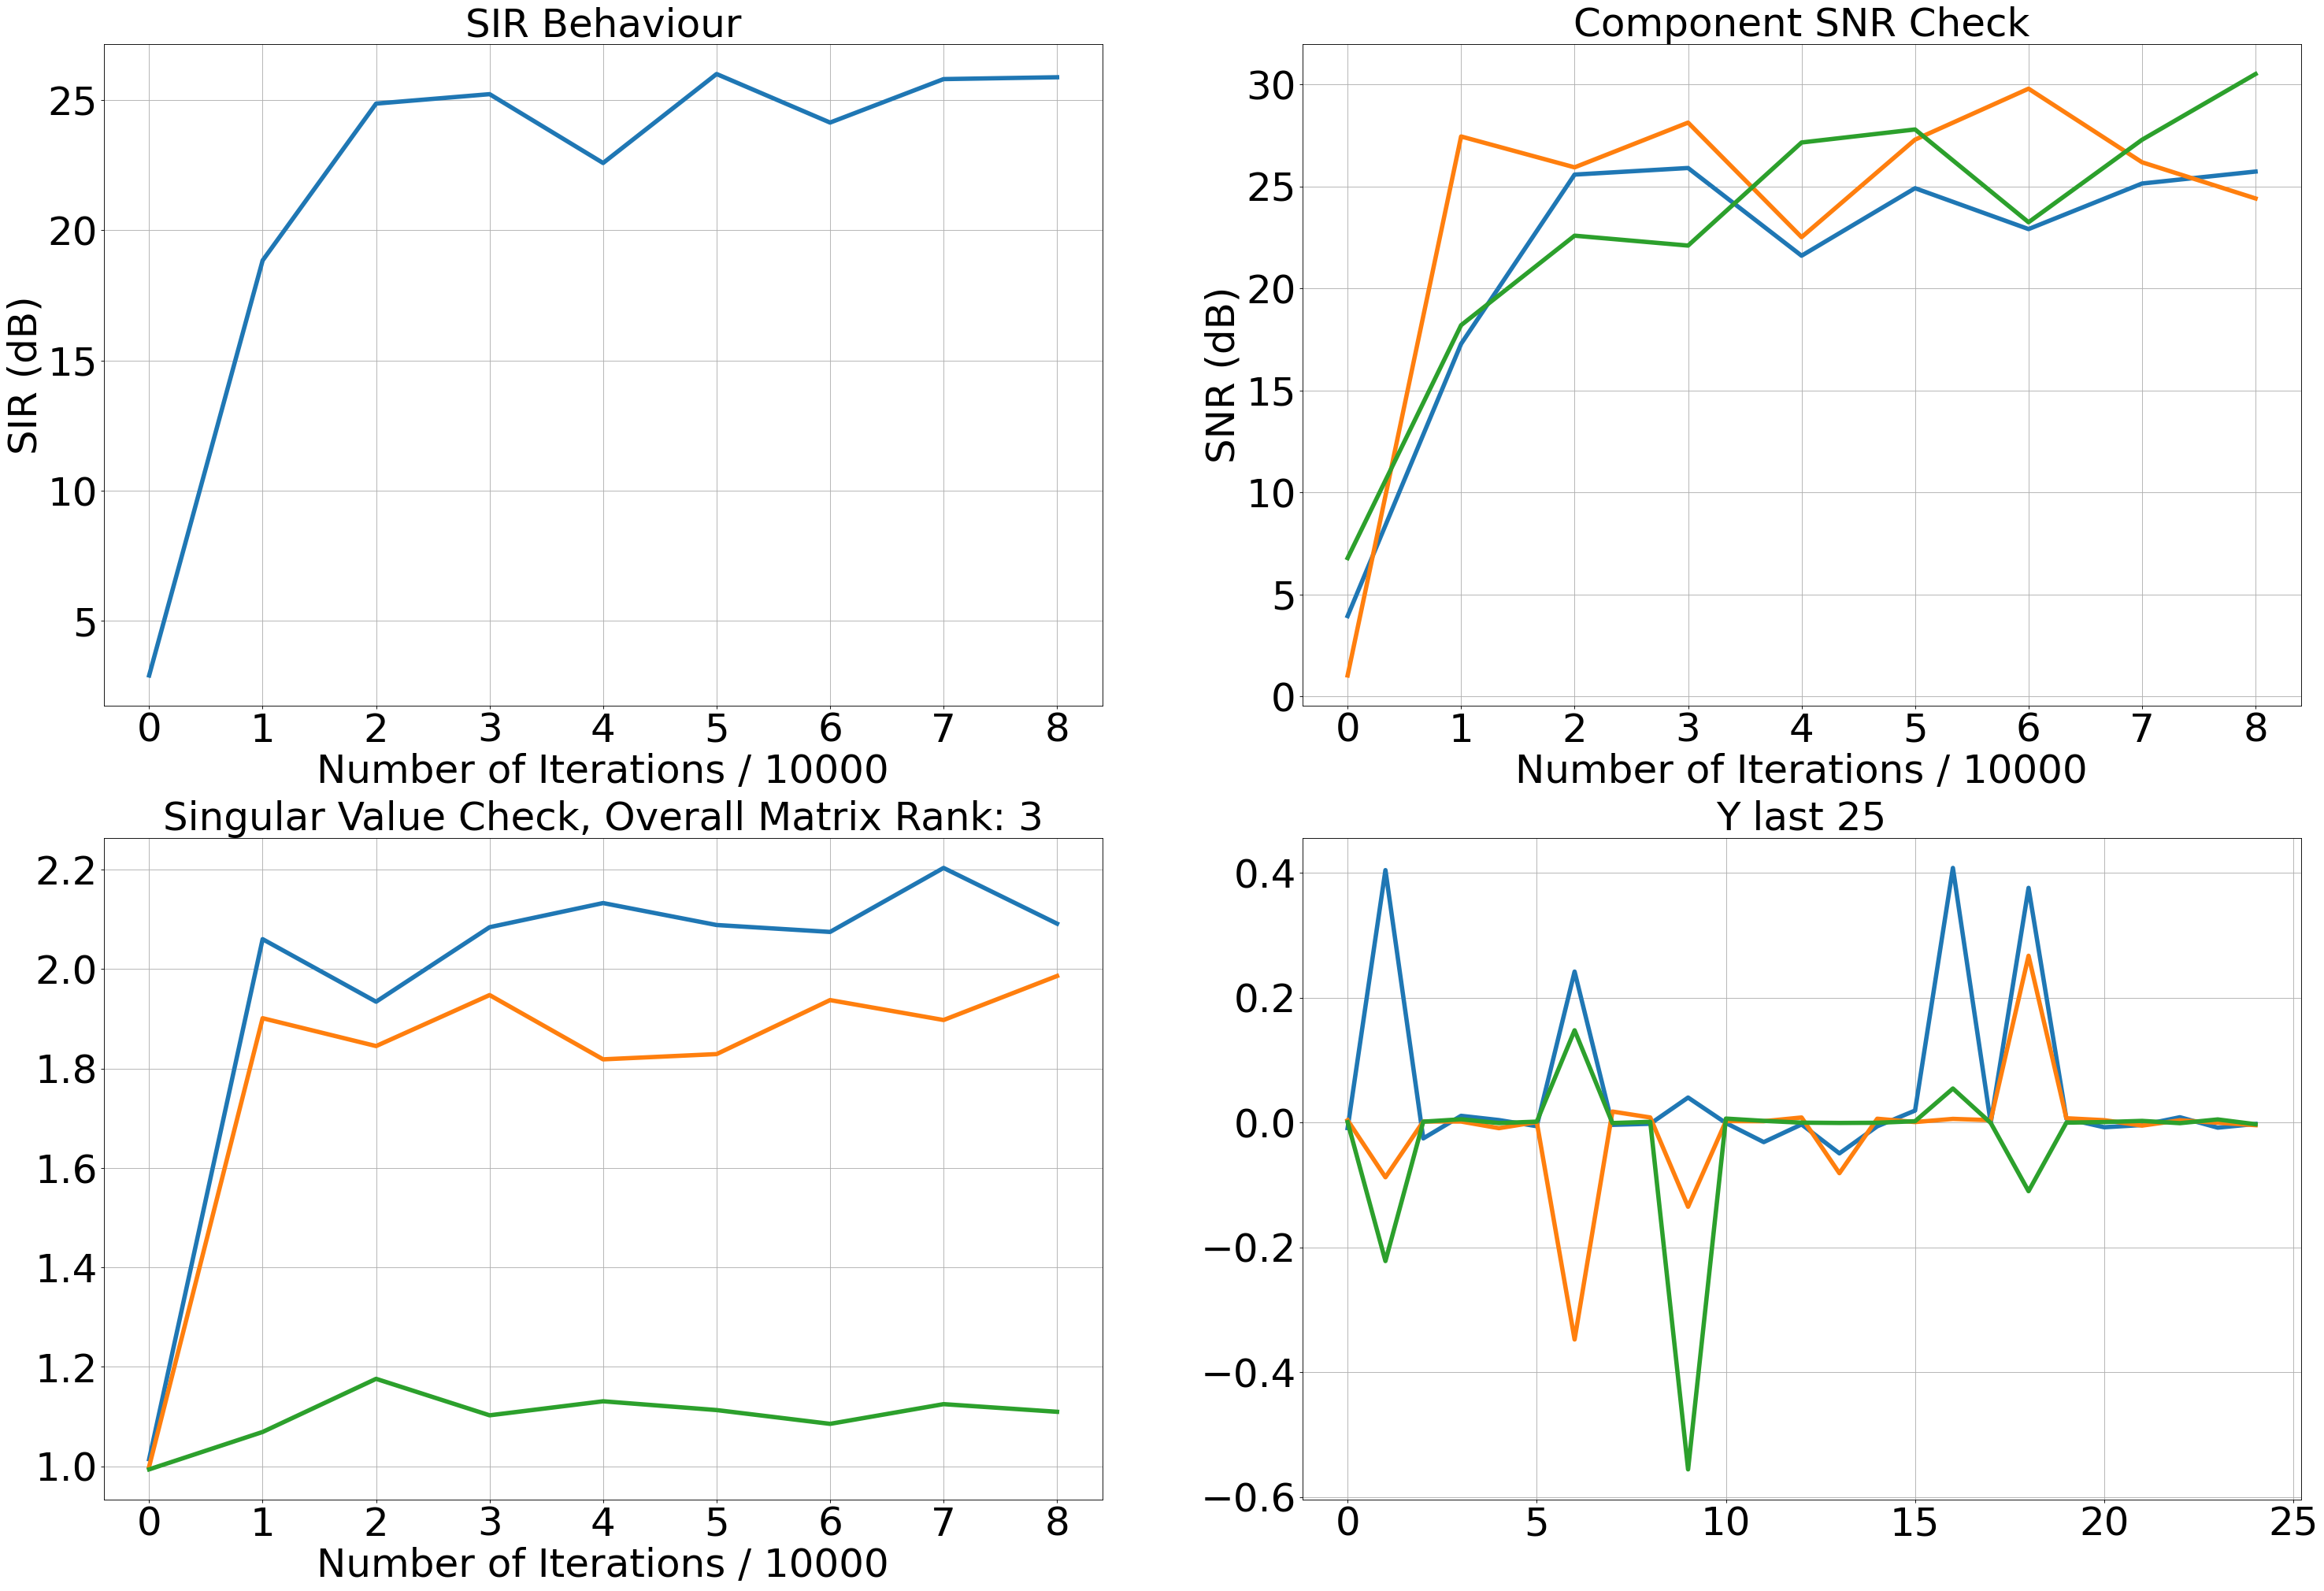

100%|██████████| 80020/80020 [01:23<00:00, 954.20it/s] 


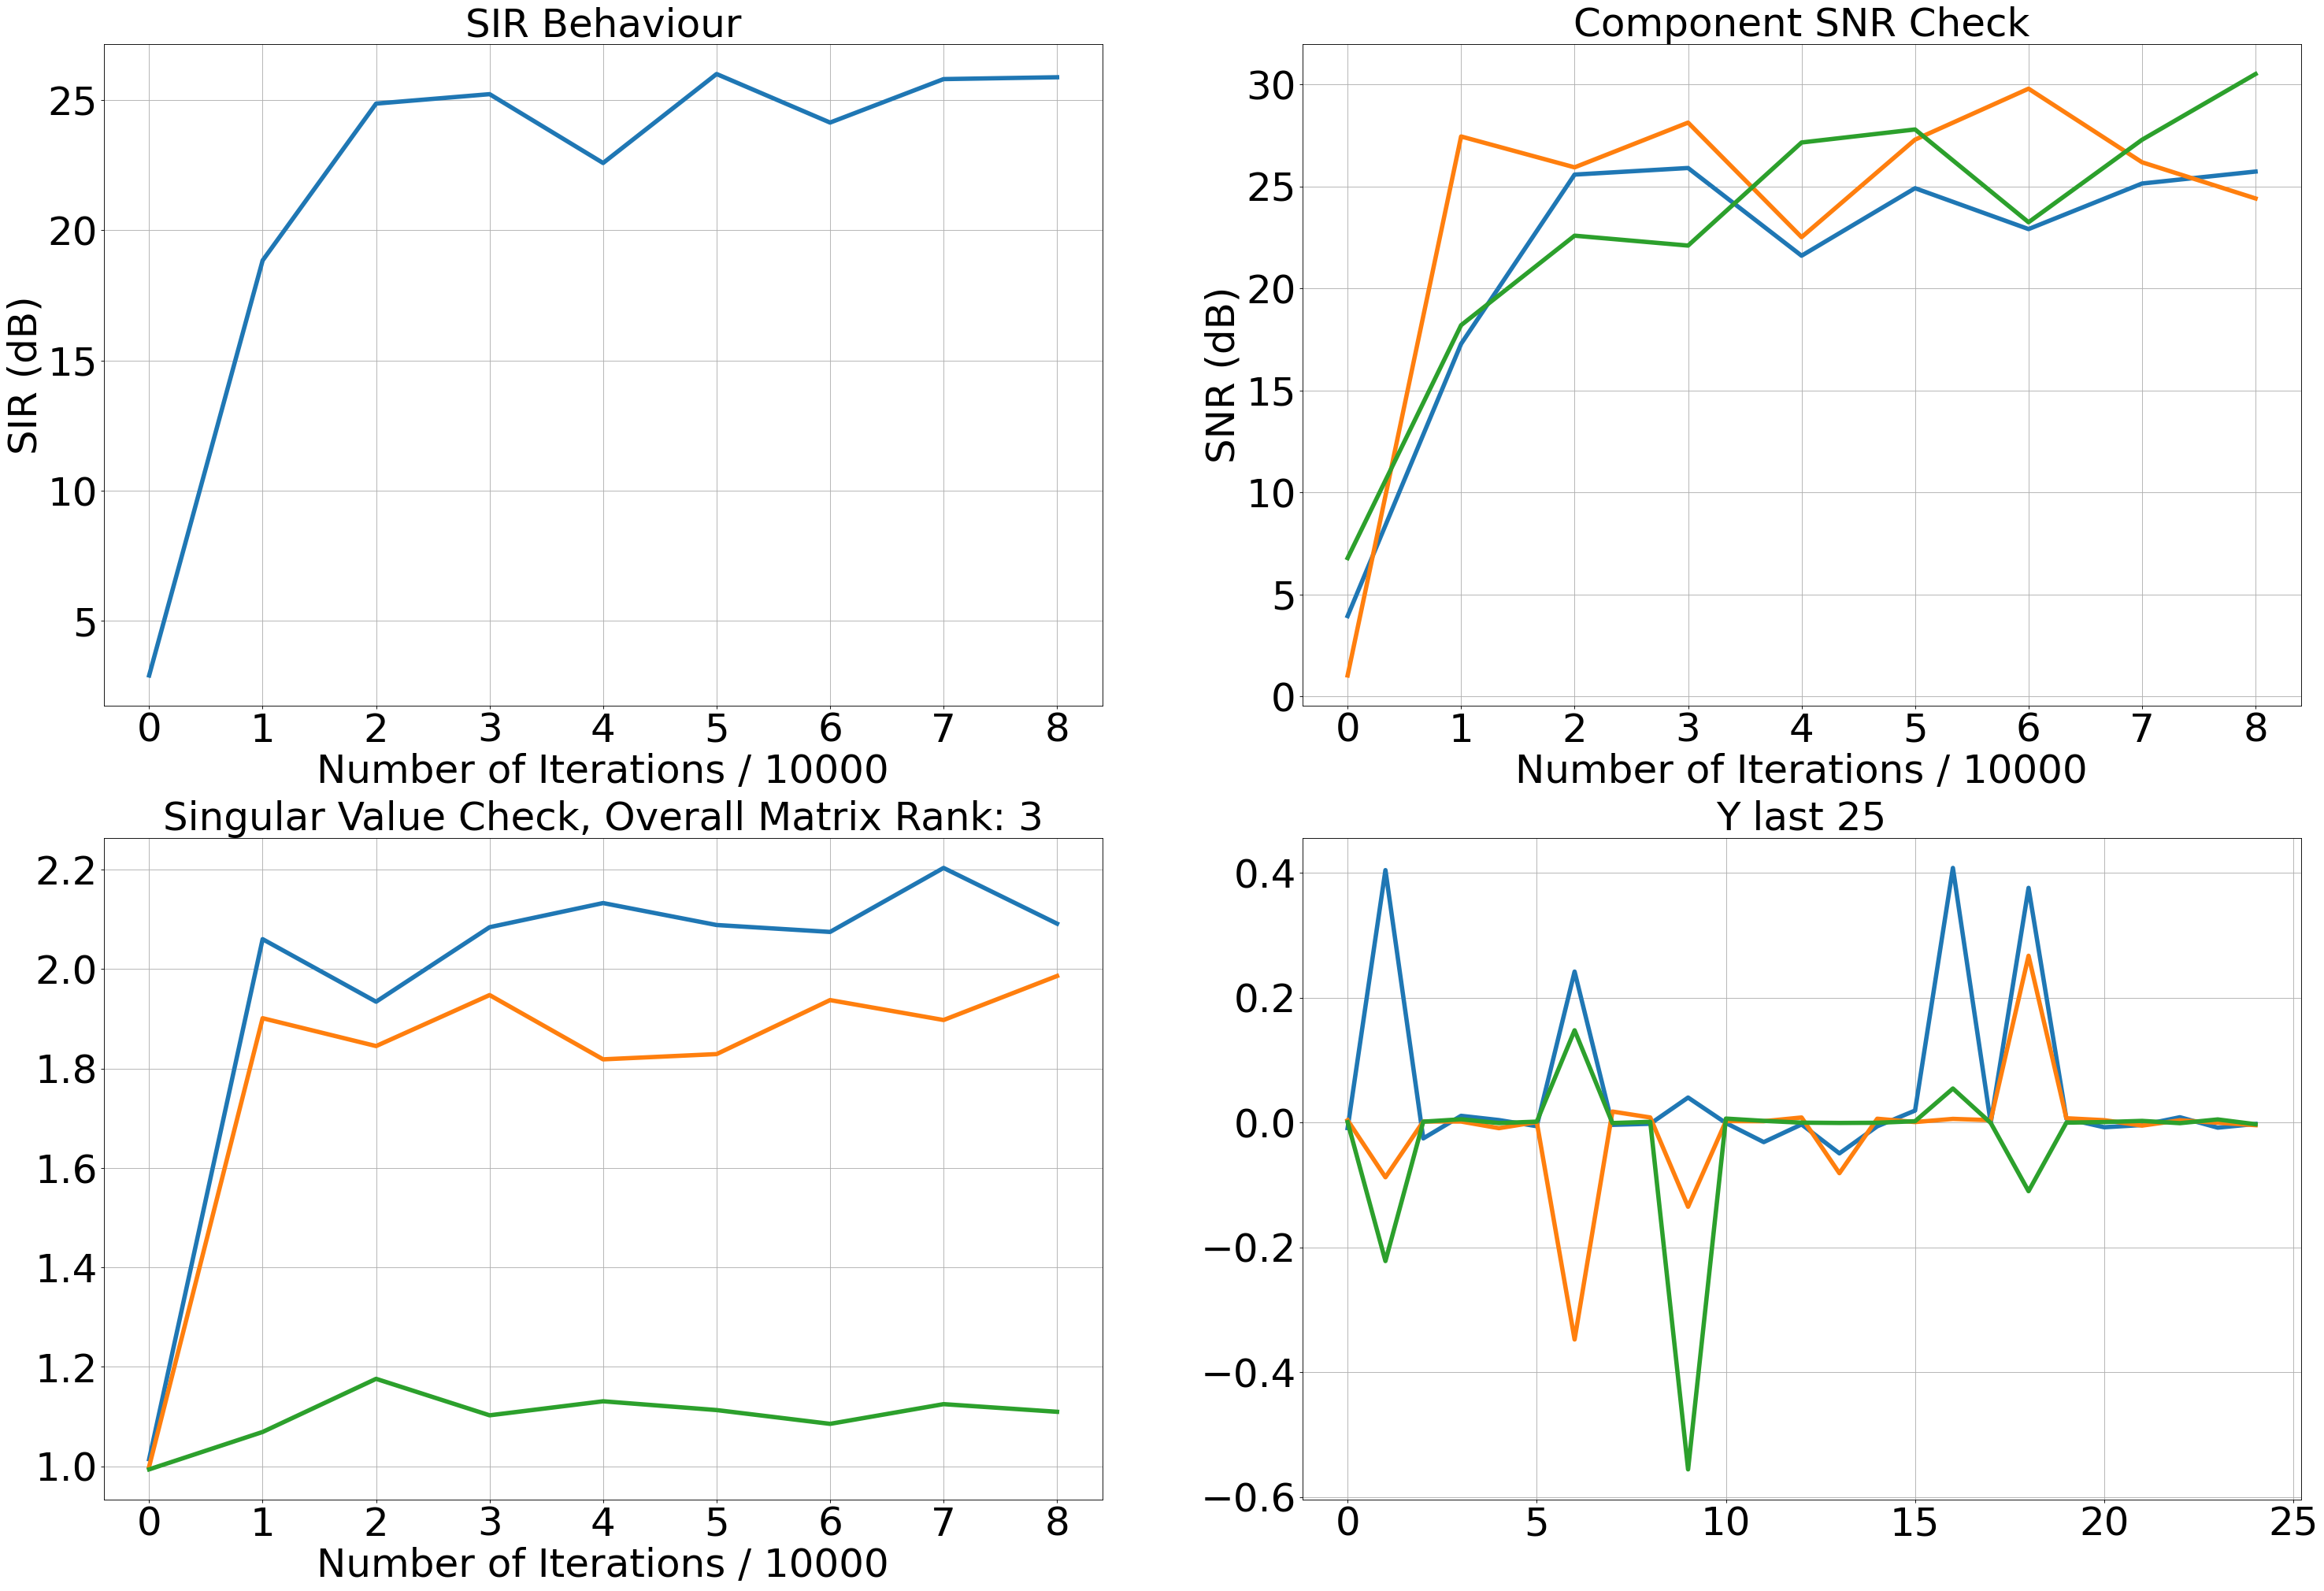

In [3]:
np.random.seed(seed)
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "sparse",
                ### Optimization parameters
                "lambda_lateral" : 0.95,
                "gamma_predictive" : 150,
                ### Learning rates 
                "lr_W" : 9.5 * 1e-1,
                "neural_lr_start" : 0.01,
                "neural_lr_stop" : 1e-4,
                "stlambda_lr" : 0.5,
                "neural_dynamics_iterations" : 100,
                "neural_OUTPUT_COMP_TOL" : 1e-6,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "divide_by_index",
                "lr_W_decay_divider" : 2000,
                "neural_lr_rule" : "divide_by_loop_index",
                "neural_lr_decay_divider" : 200,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "C_y" : None,
                "mu_y" : None, 
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S_wavelet,
                "debug_iteration_point" : 10000,
                "plot_debug_during_training" : True,
}
model = PredictiveDecorrBSS(**hyperparam_dict)
model.fit(X_wavelet, shuffle_samples = True)

In [4]:
display_matrix(model.C_y)

<IPython.core.display.Math object>

In [5]:
display_matrix(model.mu_y.reshape(1, -1))

<IPython.core.display.Math object>

In [6]:
display_matrix(model.W)

<IPython.core.display.Math object>

In [7]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(S, Y_)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 26.16958782453144
Component Signal-to-Noise-Ratio (SNR) Values : [25.76406487 24.35363461 30.52954208]



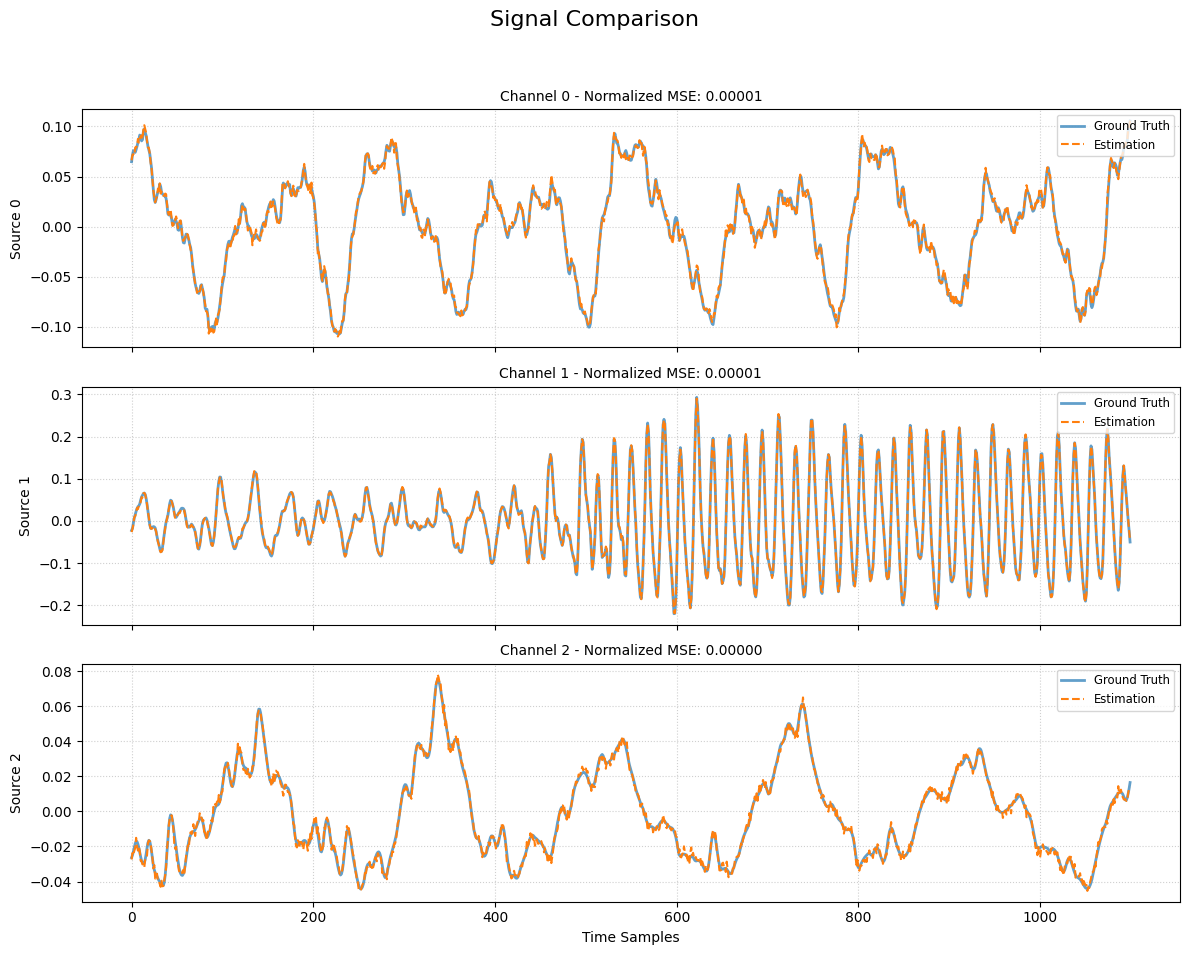

In [8]:
plot_bss_comparison(S[:, 5500:6600], Y_[:, 5500:6600])

# Plot for Publication

In [9]:
def plot_bss_sound_separation_comparison(S, Y, title="Signal Comparison", figsize=(12, 10), save_path = None):
    """
    S: Ground truth sources (n_sources, n_samples)
    Y: Estimated sources (n_sources, n_samples) - Must be pre-aligned/signed
    """
    n = S.shape[0]
    
    # # Normalize to Z-score (Mean=0, Std=1) for visual comparison
    # # This is essential because BSS has scale ambiguity
    # S_norm = (S - S.mean(axis=1, keepdims=True)) / (S.std(axis=1, keepdims=True) + 1e-9)
    # Y_norm = (Y - Y.mean(axis=1, keepdims=True)) / (Y.std(axis=1, keepdims=True) + 1e-9)
    
    fig, axes = plt.subplots(n, 1, figsize=figsize, sharex=True)
    if n == 1: axes = [axes]

    for i in range(n):
        # Plot signals
        axes[i].plot(S[i, :], label="Ground Truth", color="#1f77b4", alpha=0.7, linewidth=2)
        axes[i].plot(Y[i, :], label="Estimation", color="#ff7f0e", linestyle="--", linewidth=1.5)
        
        # Calculate local MSE for this channel
        mse = np.mean((S[i, :] - Y[i, :])**2)
        
        # axes[i].set_ylabel(f"Source {i}")
        axes[i].legend(loc="upper right", frameon=True, fontsize='small')
        axes[i].grid(True, linestyle=':', alpha=0.6)
        axes[i].set_title(f"Channel {i + 1}", fontsize=10)

    plt.xlabel("Time Samples")
    # plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save_path is not None:
        plt.savefig(save_path, format='pdf', bbox_inches = 'tight')
    plt.show()

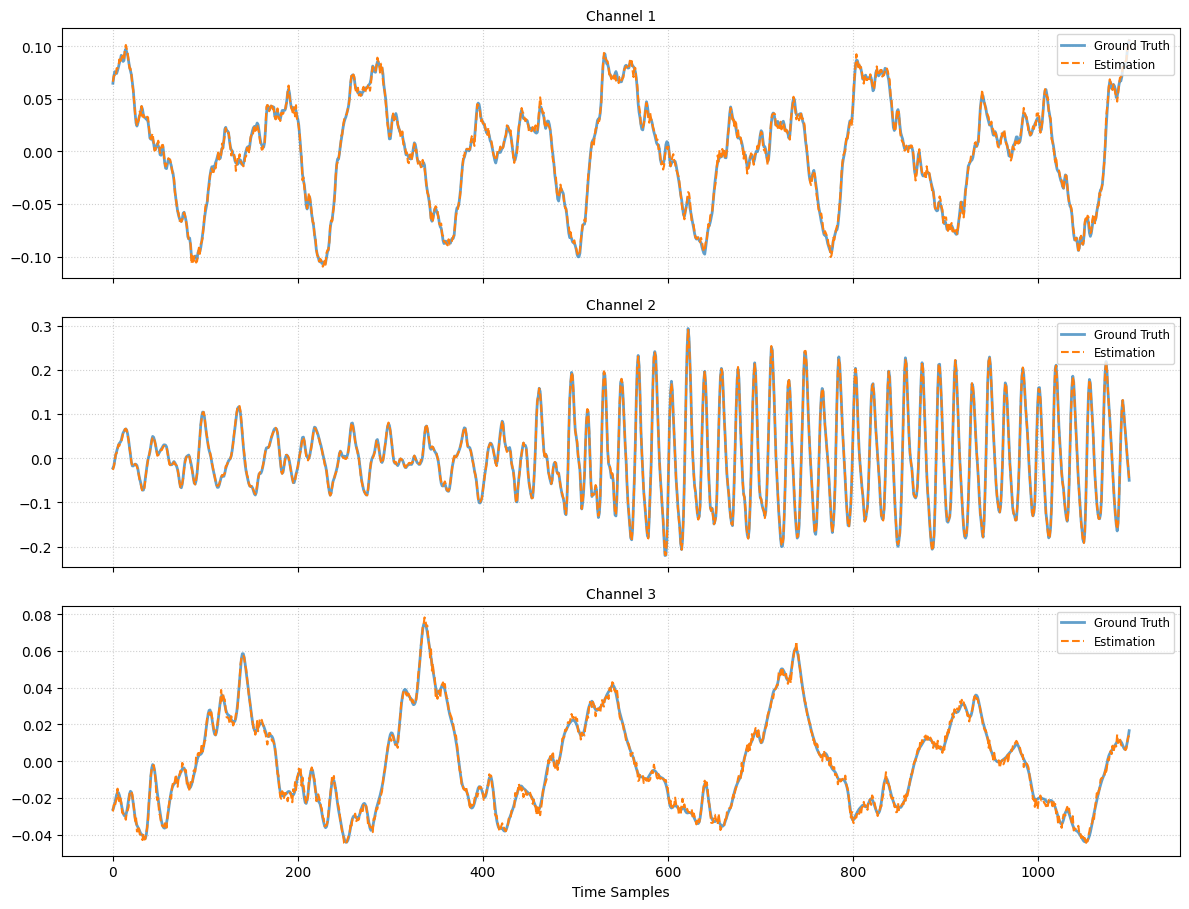

In [10]:
save_path = '../AnalyzeSimulationResults/Figures/Sound_Separation_Comparison.pdf'
plot_bss_sound_separation_comparison(S[:, 5500:6600], Y_[:, 5500:6600], save_path = save_path)